The topic of todays lab are estimators. They are a statistical tool that is used to calculate to measure an unknown parameter of a population using a sample taken from that population. Obviously, because we do not know the parameter, we can be sure of our anwser only with a certain probability.

We recognize two types of estimator: point and interval estimators. They have different properties and uses. The point estimater is used to give the exact
value of the parameter that is estimated and any parameter can be estimated by multiple functions. Thus we have several properties that we recognize that are used to define what a good estimator is(those were discussed during the lectures). Some examples of good estimators are: the mean of the sample as an estimator of the mean of the population; the proportion of one possible anwser in a sample for the proportion of that anwser in the whole population. The matter is not as simple when point estimating the variance. One could assume that it is sufficent to do what we do with the mean and calculate $$ \frac{1}{n} \sum_{i=1}^n (X_i- \bar{X})^2,$$ where $X_i$ are the values from the sample, $n$ is the size of the sample and $\bar{X}$ is the mean of the sample, but that estimator will have its expected value different from the variance of the population, and thus will be a **biased** estimator. To fix this problem we need to use the formula $$\frac{1}{n-1} \sum_{i=1}^n (X_i- \bar{X})^2$$

Point estimators are nice as they give us an exact value of the parameter we are looking for, but they have one large problem: they are correct with probability 0. That does not make them useless, but if we want to give an anwser with a non-zero probability of being right we need to give it in the form of an interval. Based on the Central Limit Theorem we can find the smallest interval for certain estimations that will have the actual value of the sought parameter with a predefind probability equal to $1 - \alpha$, where $\alpha$ is the acepted probability of being wrong. For the values that have been discussed the formulas for finding the interval estimations are:

for the mean:
$$ [ \bar{x} - z_{1-\alpha /2}\frac{s}{\sqrt{n}} , \bar{x} + z_{1-\alpha /2}\frac{s}{\sqrt{n}} ],$$ where $\bar{x}$ is the mean of the sample, $s$  is the square root of the point estimation of the variance of the sample (so an estimation of the standard diviation), $n$ is the size of the sample and $z_{1-\alpha /2}$ is the $1-\alpha /2$ quantile of the normal distribution with mean 0 and sd 1 ( we can find it by calculating the function qnorm in the value given in the index).

for the proportion:
$$[ \hat{p} - z_{1-\alpha /2}\sqrt{\frac{p(1-p)}{n}} , \hat{p} + z_{1-\alpha /2}\sqrt{\frac{p(1-p)}{n}} ],$$ where $\hat{p}$ is the proportion of the value in the sample, $p$ is an estimation of the proportion that we have from other sources (if we have none replace $p$ with $\hat{p}$), $n$ is the size of the sample and $z_{1-\alpha /2}$ is the $1-\alpha /2$ quantile of the normal distribution with mean 0 and sd 1. We can see that this interval estimation is nothing else bu the interval estimation of the mean for a certain Bernoulli distribution with the probability of success given by $\hat{p}$.


for the variance:
$$[ \frac{(n-1) s^2}{\chi^2_{1-\alpha/2,n-1}},\frac{(n-1) s^2}{\chi^2_{\alpha/2,n-1}} ],$$ where $n$ is the size of the sample, $s^2$ is the point estimator of the variance and $\chi^2_{k,n-1}$ is the $k$ quantile of the distribution $\chi^2$ with $n-1$ degrees of freedom (which we find using the function qchisq with the parameters $k$ and $n-1$ )

To get a better grasp on what estimators are please create functions to calculate the point estimators and the confidence intervals for the following statistics: the mean, the proportion, and the variance (I am aware that such functions exist in R, but please try to write them on your own). The output of each function should consist of the value of the point estimate and the values of the lower and upper bounds of the confidence interval. The confidence level should be a parameter of each function, set to 0.05 by default.

In [ ]:
daneO = read.csv2('Data/daneO.csv')
daneO

Wiek,Rozmiar.guza,Wezly.chlonne,Nowotwor,Receptory.estrogenowe,Receptory.progesteronowe,Niepowodzenia,Okres.bez.wznowy,VEGF
<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>
29,1,0,2,(-),(++),brak,22,914
29,1,0,2,(++),(++),brak,53,1118
30,1,1,2,(-),(+),brak,38,630
32,1,0,3,(++),(++),brak,26,1793
32,2,0,NA,(-),(++),brak,19,963
33,1,1,3,(-),(++),wznowa,36,2776
34,1,0,3,(-),(+),brak,33,1676
35,2,1,2,(+),(++),brak,38,3827
35,1,1,3,(-),(-),wznowa,38,22554


In [2]:
estimate_mean <- function(x, alpha = 0.05) {
  x <- na.omit(x)
  n <- length(x)
  x_bar <- mean(x)
  s <- sd(x)
  z <- qnorm(1 - alpha / 2)
  margin <- z * s / sqrt(n)
  cat("Point estimate (mean):", x_bar, "\n")
  cat("Confidence interval:  [", x_bar - margin, ",", x_bar + margin, "]\n")
  invisible(list(estimate = x_bar, lower = x_bar - margin, upper = x_bar + margin))
}


estimate_proportion <- function(x, p_prior = NULL, alpha = 0.05) {
  x <- na.omit(x)
  n <- length(x)
  p_hat <- mean(x)
  p_use <- if (!is.null(p_prior)) p_prior else p_hat
  z <- qnorm(1 - alpha / 2)
  margin <- z * sqrt(p_use * (1 - p_use) / n)
  cat("Point estimate (proportion):", p_hat, "\n")
  cat("Confidence interval:        [", p_hat - margin, ",", p_hat + margin, "]\n")
  invisible(list(estimate = p_hat, lower = p_hat - margin, upper = p_hat + margin))
}


estimate_variance <- function(x, alpha = 0.05) {
  x <- na.omit(x)
  n <- length(x)
  s2 <- var(x)
  lower <- (n - 1) * s2 / qchisq(1 - alpha / 2, df = n - 1)
  upper <- (n - 1) * s2 / qchisq(alpha / 2,     df = n - 1)
  cat("Point estimate (variance):", s2, "\n")
  cat("Confidence interval:      [", lower, ",", upper, "]\n")
  invisible(list(estimate = s2, lower = lower, upper = upper))
}

Create a vector named H of 1000 random values drawn from a normal distribution with mean 1.8 an standard deviation equal to 0.3. Find the mean value of this vector. Next, for 100 samples of size 100 drawn from this vector, using the function you created previously find the percentage of the cases for which the mean of the whole population lies in the confidence interval of the sample.

In [3]:
set.seed(42)
H <- rnorm(1000, mean = 1.8, sd = 0.3)
true_mean <- mean(H)
cat("Mean of H:", true_mean, "\n")

coverage <- replicate(100, {
  s <- sample(H, size = 100)
  ci <- estimate_mean(s, alpha = 0.05)
  ci$lower <= true_mean && true_mean <= ci$upper
})

cat("Coverage percentage:", mean(coverage) * 100, "%\n")

Mean of H: 1.792253 
Point estimate (mean): 1.821561 
Confidence interval:  [ 1.759819 , 1.883302 ]
Point estimate (mean): 1.787864 
Confidence interval:  [ 1.727376 , 1.848352 ]
Point estimate (mean): 1.782204 
Confidence interval:  [ 1.723164 , 1.841244 ]
Point estimate (mean): 1.753532 
Confidence interval:  [ 1.698372 , 1.808691 ]
Point estimate (mean): 1.81537 
Confidence interval:  [ 1.752853 , 1.877887 ]
Point estimate (mean): 1.813042 
Confidence interval:  [ 1.750794 , 1.87529 ]
Point estimate (mean): 1.848755 
Confidence interval:  [ 1.785197 , 1.912313 ]
Point estimate (mean): 1.849425 
Confidence interval:  [ 1.789772 , 1.909077 ]
Point estimate (mean): 1.805019 
Confidence interval:  [ 1.750471 , 1.859568 ]
Point estimate (mean): 1.8209 
Confidence interval:  [ 1.759759 , 1.882041 ]
Point estimate (mean): 1.786974 
Confidence interval:  [ 1.723644 , 1.850305 ]
Point estimate (mean): 1.821513 
Confidence interval:  [ 1.756476 , 1.88655 ]
Point estimate (mean): 1.789609 
Con

The data in daneO.csv contains information about breast cancer treatment for 97 patients. The data in Niepowodzenia describes whether there was a relapse or on ("brak" stands for no and "wznowa" for yes ). Estimate the proportion of relapses, with the confidence interval, using the function you created in, once assuming the proportion in the population is 0.5, and a second time assuming it is 0.1.

In [4]:
relapses <- as.integer(trimws(daneO$Niepowodzenia) == "wznowa")

cat("--- Assuming p_prior = 0.5 ---\n")
estimate_proportion(relapses, p_prior = 0.5)

cat("\n--- Assuming p_prior = 0.1 ---\n")
estimate_proportion(relapses, p_prior = 0.1)

--- Assuming p_prior = 0.5 ---
Point estimate (proportion): 0.1340206 
Confidence interval:        [ 0.03451852 , 0.2335227 ]

--- Assuming p_prior = 0.1 ---
Point estimate (proportion): 0.1340206 
Confidence interval:        [ 0.07431936 , 0.1937219 ]


As it was mentioned there are functions in R that can find the estimators for us. One of the universal functions made for that purpose is the fitdistr() from the library MASS. Its first parameter is the sample which you want to use for the estimation. The second is the class of distributions that you think your population is a part of (so you need to have some idea of what the distribution looks like). Depending on the class you sometimes need to set starting parameters so and point from which the function should start to look for the actual estimations (this is not always needed for example it's not for the normal distribution).
Use the fitdistr() function to estimate the parameters of the H vector created before. Next draw a histogram of VEGF from daneO and choose a proper distribution and estimate its parameters using the fitdistr() function.

    meanlog       sdlog   
  7.27684012   1.09812091 
 (0.11149729) (0.07884049)


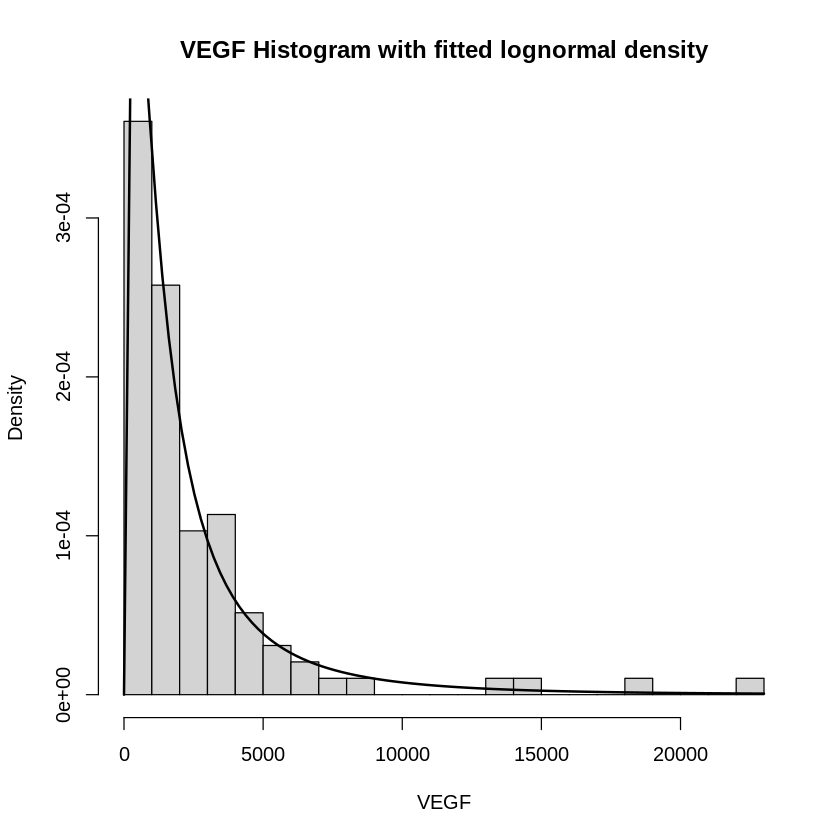

In [12]:
library(MASS)

vegf <- na.omit(daneO$VEGF)

hist(vegf, breaks = 20, probability = TRUE,
     main = "VEGF Histogram with fitted lognormal density",
     xlab = "VEGF")

curve(dlnorm(x,
             meanlog = fit_VEGF$estimate["meanlog"],
             sdlog = fit_VEGF$estimate["sdlog"]),
      add = TRUE,
      lwd = 2)

fit_VEGF <- fitdistr(vegf, "lognormal")
print(fit_VEGF)

In some cases the size of the sample will be too small to justify using statistical methods of parameter estimation. In those cases there is an interesting method of create a better sample for our purposes. It is called the **bootstrap** method. Basically it uses the sample we have, treats it as a population and draws from it a sample of an reasonable size. It can just use the values form the sample in which case all of the values are from the sample, or we can replicate the values from the distribution we think the original sample was taken from, in which case there can be values that don't appear in the original sample.

For our tasks we will use the function boot() from the boot package. Its parameter data should containg the sample we are using the technique on. The parameter sim="ordinary" will give a bootstrap taken by using the values from the sample, while sim="parametric" will alllow to tate the values from a certain distribution. Parameter R defines the number of replications we are looking for, and statistic is the statistic funcion (in our case the estimator) we are looking to test. We also define the method in which the bootstrap gives the applies the genetated values to our statistics function using the parameter stype. For the value "i" it applies the indexes of the values replicated from the original sample. For "f" it applies the number of repetitions of the values created. For "w" it gives the relative frequencies of the values created. Once you created the bootstrap replication you can find the confidence intervals for that estimator using the function boot.ci().

Having all that in mind please find the confidence intervals for the mean of the data VEGF from dane0, using the bootstrap method, based on 1000 repetitions.

In [6]:
library(boot)

mean_fn <- function(data, i) mean(data[i])

boot_vegf <- boot(data = daneO$VEGF, statistic = mean_fn, R = 1000, sim = "ordinary", stype = "i")
print(boot_vegf)

boot.ci(boot_vegf, type = c("perc", "bca"))


ORDINARY NONPARAMETRIC BOOTSTRAP


Call:
boot(data = daneO$VEGF, statistic = mean_fn, R = 1000, sim = "ordinary", 
    stype = "i")


Bootstrap Statistics :
    original   bias    std. error
t1* 2626.608 4.014959    362.2092


BOOTSTRAP CONFIDENCE INTERVAL CALCULATIONS
Based on 1000 bootstrap replicates

CALL : 
boot.ci(boot.out = boot_vegf, type = c("perc", "bca"))

Intervals : 
Level     Percentile            BCa          
95%   (1982, 3409 )   (2057, 3553 )  
Calculations and Intervals on Original Scale

Use the bootstrap technique without parameters on a sample of 50 elements from the vector H  to estimate the mean of that population. Compare the result to the actual value.

In [7]:
set.seed(42)
H_sample <- sample(H, size = 50)

boot_H <- boot(data = H_sample, statistic = mean_fn, R = 1000, sim = "ordinary", stype = "i")
print(boot_H)
ci_H <- boot.ci(boot_H, type = c("perc", "bca"))
print(ci_H)

cat("\nActual mean of H:", mean(H), "\n")
cat("Bootstrap mean estimate:", boot_H$t0, "\n")


ORDINARY NONPARAMETRIC BOOTSTRAP


Call:
boot(data = H_sample, statistic = mean_fn, R = 1000, sim = "ordinary", 
    stype = "i")


Bootstrap Statistics :
    original       bias    std. error
t1* 1.863611 -0.002183029  0.04465876
BOOTSTRAP CONFIDENCE INTERVAL CALCULATIONS
Based on 1000 bootstrap replicates

CALL : 
boot.ci(boot.out = boot_H, type = c("perc", "bca"))

Intervals : 
Level     Percentile            BCa          
95%   ( 1.776,  1.950 )   ( 1.779,  1.954 )  
Calculations and Intervals on Original Scale

Actual mean of H: 1.792253 
Bootstrap mean estimate: 1.863611 
